In [23]:
#import statements
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
#importing the dataset file
survey_df = pd.read_csv(r"C:\Users\Andrew\Desktop\The Frontier Institute - Programs\Data Science Program Stuff\survey_results_public.csv")

In [25]:
#viewing the data, and unique values for the Age column
survey_df.head()
survey_df["Age"].unique()

<StringArray>
['Under 18 years old',    '35-44 years old',    '45-54 years old',
    '18-24 years old',    '25-34 years old',    '55-64 years old',
  'Prefer not to say',  '65 years or older']
Length: 8, dtype: str

In [26]:
print(survey_df.columns.tolist())

['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith',

In [27]:
survey_df = survey_df.drop(columns = ['JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 
                                      'JobSatPoints_10', 'JobSatPoints_11', 'TimeSearching', 'TimeAnswering', 'SurveyLength', 'SurveyEase', 'Check', 'SOVisitFreq', 'SOAccount',
                                      'SOPartFreq', 'SOHow', 'SOComm', 'NEWSOSites', 'Frequency_1', 'Frequency_2', 'Frequency_3', 'Knowledge_1' , 'Knowledge_2', 'Knowledge_3', 
                                      'Knowledge_4', 'Knowledge_5', 'Knowledge_6', 'Knowledge_7', 'Knowledge_8', 'Knowledge_9'])
survey_df.head(3)

,ResponseId,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,...,TBranch,ICorPM,WorkExp,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,...,Yes,Individual contributor,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
survey_df['AISearchDevHaveWorkedWith'].unique()
survey_df['YearsCodePro'].unique()
print(survey_df.loc[survey_df["YearsCodePro"].isnull(), "YearsCodePro"])


0        NaN
3        NaN
4        NaN
5        NaN
7        NaN
        ... 
65427    NaN
65429    NaN
65430    NaN
65433    NaN
65436    NaN
Name: YearsCodePro, Length: 13827, dtype: str


In [29]:
#drops all rows with null values in the "YearsCodePro" column
survey_df = survey_df.dropna(subset=['YearsCodePro'])

corrected_years = [] #empty list to store corrected years

#for loop, cycles through "YearsCodePro" column, and replaces string values with rounded integers
for year in survey_df['YearsCodePro']:
   if year == "Less than 1 year":  #rounuds "Less than 1 year" to 0 years
        corrected_years.append(0)
   elif year == "More than 50 years":
      corrected_years.append(51)  #rounuds "More than 50 years" to 51 years
   else:
       corrected_years.append(int(year))       
survey_df['YearsCodePro'] = corrected_years

survey_df['YearsCodePro'] #test to make sure code worked

1        17
2        27
6         7
9        11
11       25
         ..
65428     7
65431    24
65432     3
65434     5
65435     2
Name: YearsCodePro, Length: 51610, dtype: int64

In [30]:
age_numbers = []

#for loop: cycles through the dataset, and uses conditional to assign a numerical value to age ranges
#Adds the numbers in a list, into a new column, corresponding to each row
for age in survey_df['Age']:
    if age == 'Under 18 years old':
        age_numbers.append(1)      # 1 --> <18
    elif age == '18-24 years old':
        age_numbers.append(2)      # 2 --> 18-24
    elif age == '25-34 years old':
        age_numbers.append(3)      # 3 --> 25-34
    elif age == '35-44 years old':
        age_numbers.append(4)      # 4 --> 35-44
    elif age == '45-54 years old':
        age_numbers.append(5) # 5 --> 45-54
    elif age == '55-64 years old':
        age_numbers.append(6) # 6 --> 55-64
    elif age == '65 years or older':
        age_numbers.append(7) # 7 --> 65+
    else:
        age_numbers.append(-0)    # For 'prefer not to say'

# Put the list back into the dataset
survey_df['AgeCategory'] = age_numbers
survey_df.insert(3, 'AgeCategory', survey_df.pop('AgeCategory')) #Moves the column right beside 'Age', the 3rd index
survey_df.head(3)

,ResponseId,MainBranch,Age,AgeCategory,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,TBranch,ICorPM,WorkExp,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,ConvertedCompYearly,JobSat
1,2,I am a developer by profession,35-44 years old,4,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,Yes,Individual contributor,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,5,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,"I am not primarily a developer, but I write co...",35-44 years old,4,"Employed, full-time",Remote,I don’t code outside of work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Written...,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


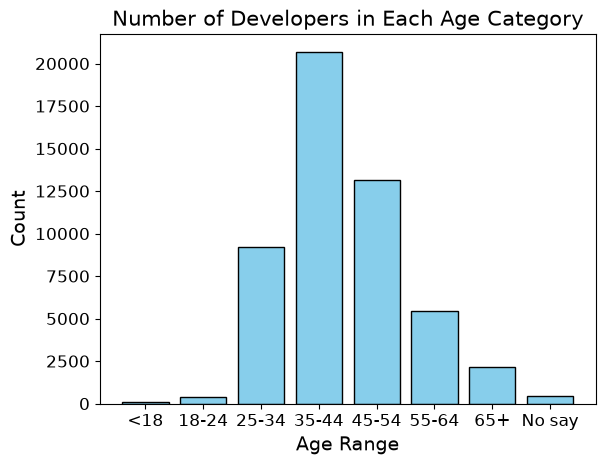

In [38]:
#Gets counts of the age category, sorted from 0-7
age_counts = survey_df['AgeCategory'].value_counts().sort_index()

#plotting bar ,graph, with some color
plt.bar(age_counts.index, age_counts.values, color='skyblue', edgecolor='black')

#using labels to force x axis to read the age ranges, instead of 0-7
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'No say']
plt.xticks(ticks=age_counts.index[:8], labels=labels)

plt.title("Number of Developers in Each Age Category")
plt.xlabel("Age Range")
plt.ylabel("Count")
plt.show()